## importing Libraries

In [11]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import missingno as ms
import traceback

import warnings
warnings.filterwarnings("ignore")

In [2]:
%run "C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/src/data/data_ingestion.py"
%run "C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/src/data/data_validation.py"

current location:  C:\Users\KISHORE\OneDrive\Desktop\Intelligent Weather Prediction Pipeline\notebooks
loading time 0.12secs
Filename: C:\Users\KISHORE\OneDrive\Desktop\Intelligent Weather Prediction Pipeline\src\data\data_ingestion.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    31    204.3 MiB    204.3 MiB           1   @profile
    32                                         def load_data(filename,filelocation):
    33                                             """
    34                                             Collects Weather data of Delhi for weather forcasting pipeline
    35                                         
    36                                             Args:
    37                                                 filename(String): Name of the file
    38                                                 filelocation(String): file location in local machine
    39                                         
    40                                  

In [3]:
os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline")
from src.data import data_ingestion
from src.data import data_validation

In [4]:
np.set_printoptions(precision = 4 , suppress = True)
pd.set_option("display.float_format" , "{:.4f}".format)

## Loading & Data Cleaning

In [5]:
weather_data = data_ingestion.load_data("open-meteo-26.61N81.26E120m","C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/data/raw")

loading time 0.11secs
Filename: C:\Users\KISHORE\OneDrive\Desktop\Intelligent Weather Prediction Pipeline\src\data\data_ingestion.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    31    213.7 MiB    213.7 MiB           1   @profile
    32                                         def load_data(filename,filelocation):
    33                                             """
    34                                             Collects Weather data of Delhi for weather forcasting pipeline
    35                                         
    36                                             Args:
    37                                                 filename(String): Name of the file
    38                                                 filelocation(String): file location in local machine
    39                                         
    40                                             Returns:
    41                                                 Dataset(DataFrame): it conta

In [6]:
weather_data.head(2)

,time,temperature_2m (°C),relative_humidity_2m (%),rain (mm),soil_temperature_0_to_7cm (°C),wind_speed_100m (km/h),surface_pressure (hPa),pressure_msl (hPa),is_day ()
0,2020-01-01T00:00,5.8000,93,0.0000,8.3000,15.1000,1004.5000,1019.4000,0
1,2020-01-01T01:00,5.7000,93,0.0000,8.0000,14.5000,1004.4000,1019.3000,0


In [7]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   time                            52608 non-null  object 
 1   temperature_2m (°C)             52608 non-null  float64
 2   relative_humidity_2m (%)        52608 non-null  int64  
 3   rain (mm)                       52608 non-null  float64
 4   soil_temperature_0_to_7cm (°C)  52608 non-null  float64
 5   wind_speed_100m (km/h)          52608 non-null  float64
 6   surface_pressure (hPa)          52608 non-null  float64
 7   pressure_msl (hPa)              52608 non-null  float64
 8   is_day ()                       52608 non-null  int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 3.6+ MB


- **we clerly observe, there is no any missing values in dataset.**

### i) Check Order of the data(Date)

In [8]:
weather_data.index.is_monotonic_increasing

True

- **observations are arranged in chronological order.**

### ii) Duplicate Records

In [9]:
weather_data[weather_data.duplicated()]

,time,temperature_2m (°C),relative_humidity_2m (%),rain (mm),soil_temperature_0_to_7cm (°C),wind_speed_100m (km/h),surface_pressure (hPa),pressure_msl (hPa),is_day ()


- **there is no any duplicate records in dataset**

### iii) Null Values

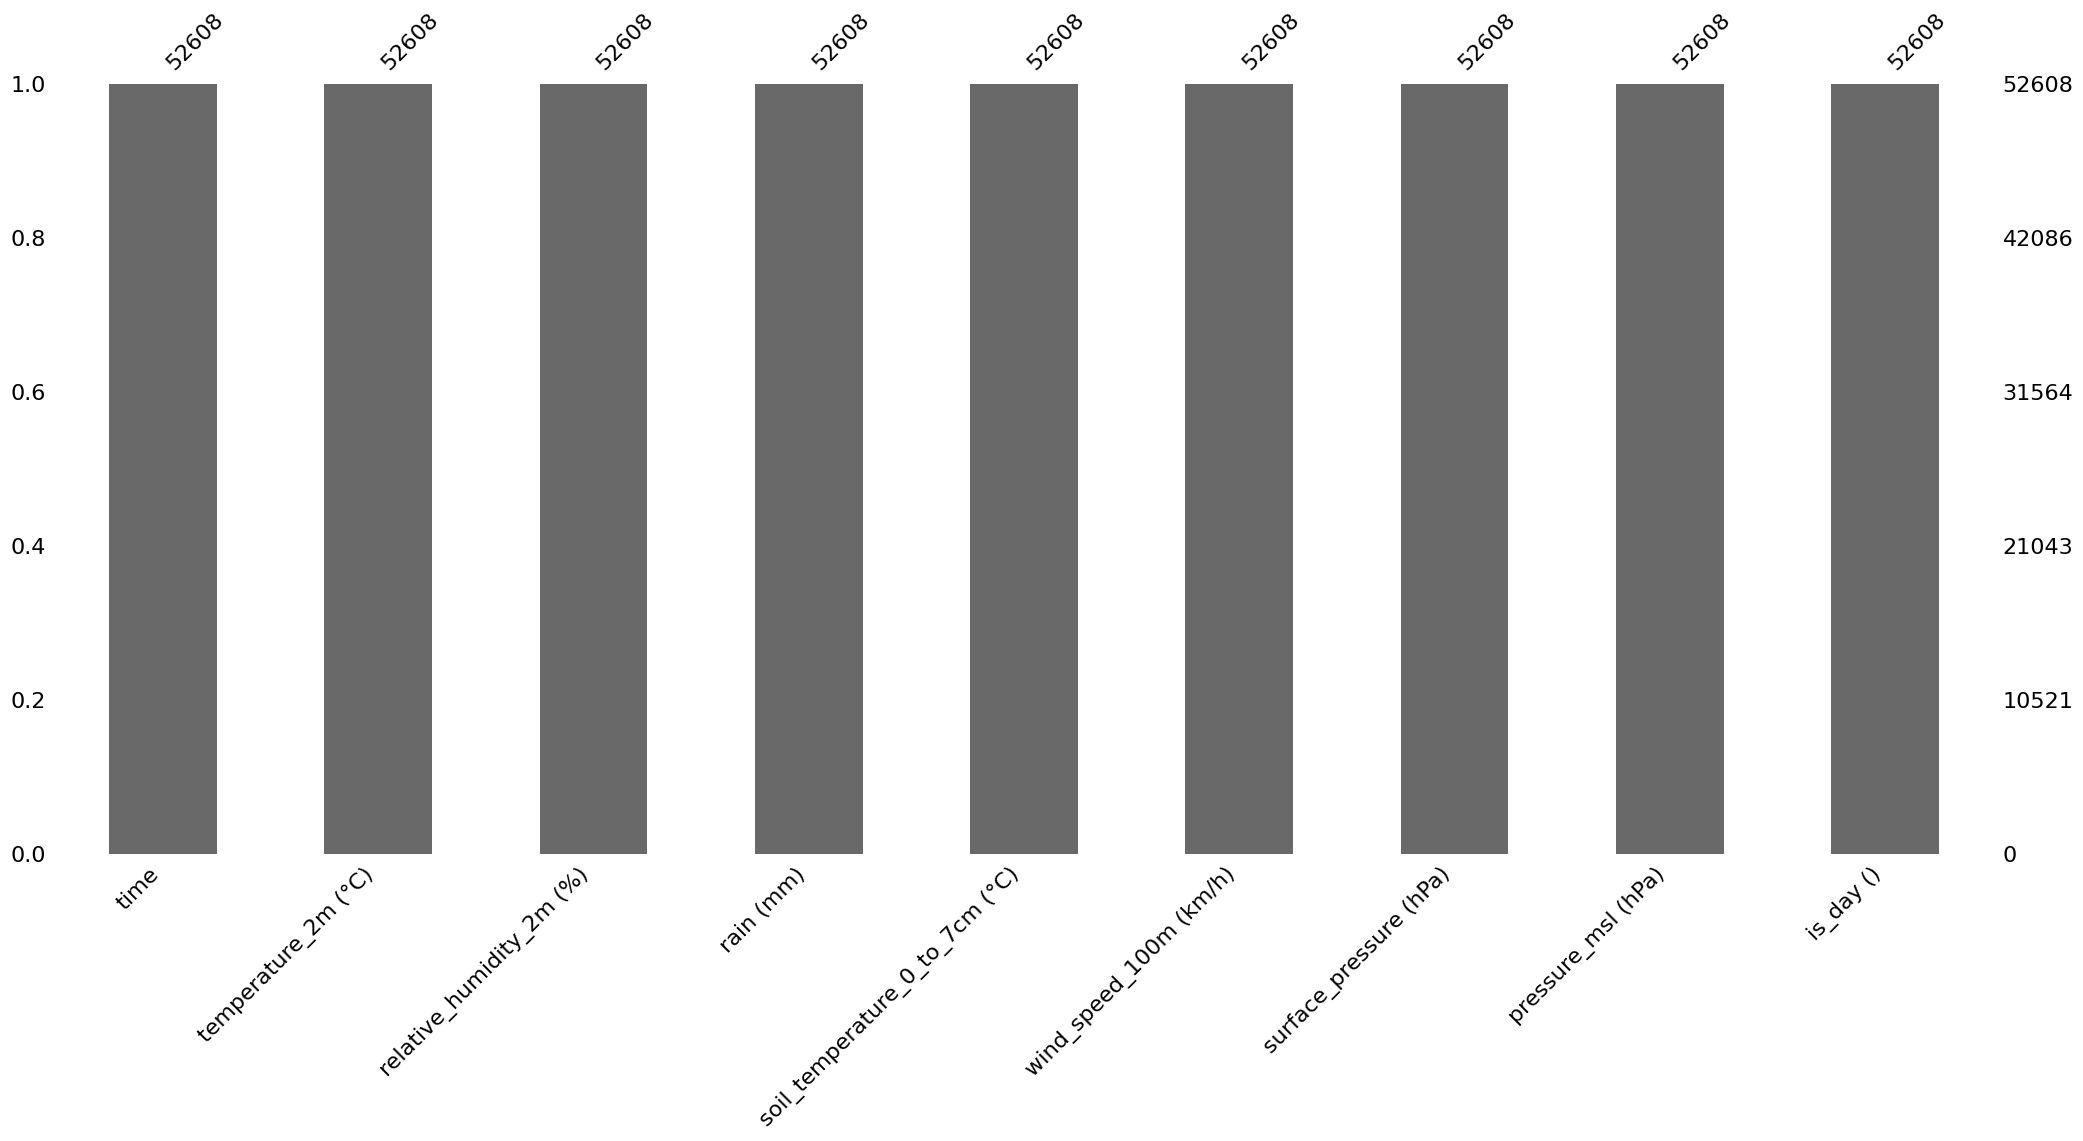

In [15]:
plt.figure(figsize = (1,1))
ms.bar(weather_data)
plt.show()

### iv) Rename columns & Data Validation

In [16]:
list(weather_data.columns)

['time',
 'temperature_2m (°C)',
 'relative_humidity_2m (%)',
 'rain (mm)',
 'soil_temperature_0_to_7cm (°C)',
 'wind_speed_100m (km/h)',
 'surface_pressure (hPa)',
 'pressure_msl (hPa)',
 'is_day ()']

In [17]:
weather_data.columns = weather_data.columns.str.strip()

In [18]:
weather_data.rename(columns = {
    "time" : "Date",
    "temperature_2m (°C)" : "Temperature",
    "relative_humidity_2m (%)" : "Relative_humidity",
    "rain (mm)" : "Rain",
    "soil_temperature_0_to_7cm (°C)" : "Soil_temperature",
    "wind_speed_100m (km/h)" : "Wind_speed",
    "surface_pressure (hPa)" : "Surface_pressure",
    "pressure_msl (hPa)" : "Pressure_msl",
    "is_day ()" : "is_day"
}, inplace = True)

In [19]:
weather_data.head()

,Date,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day
0,2020-01-01T00:00,5.8000,93,0.0000,8.3000,15.1000,1004.5000,1019.4000,0
1,2020-01-01T01:00,5.7000,93,0.0000,8.0000,14.5000,1004.4000,1019.3000,0
2,2020-01-01T02:00,6.0000,93,0.0000,7.8000,12.7000,1004.6000,1019.4000,0
3,2020-01-01T03:00,5.8000,94,0.0000,7.6000,12.3000,1004.6000,1019.5000,0
4,2020-01-01T04:00,5.7000,95,0.0000,7.6000,13.1000,1004.7000,1019.6000,0


In [20]:
weather_data["Date"] = pd.to_datetime(weather_data["Date"])

In [21]:
data_validation.validate_dataset(weather_data)

'Dataset Validated Successfully.There is no any inconsisties in data!'

- **therefore, dataset not have any incosisten datatypes & formats.**

In [22]:
weather_data.head()

,Date,Temperature,Relative_humidity,Rain,Soil_temperature,Wind_speed,Surface_pressure,Pressure_msl,is_day
0,2020-01-01 00:00:00,5.8000,93,0.0000,8.3000,15.1000,1004.5000,1019.4000,0
1,2020-01-01 01:00:00,5.7000,93,0.0000,8.0000,14.5000,1004.4000,1019.3000,0
2,2020-01-01 02:00:00,6.0000,93,0.0000,7.8000,12.7000,1004.6000,1019.4000,0
3,2020-01-01 03:00:00,5.8000,94,0.0000,7.6000,12.3000,1004.6000,1019.5000,0
4,2020-01-01 04:00:00,5.7000,95,0.0000,7.6000,13.1000,1004.7000,1019.6000,0


In [23]:
weather_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               52608 non-null  datetime64[ns]
 1   Temperature        52608 non-null  float64       
 2   Relative_humidity  52608 non-null  int64         
 3   Rain               52608 non-null  float64       
 4   Soil_temperature   52608 non-null  float64       
 5   Wind_speed         52608 non-null  float64       
 6   Surface_pressure   52608 non-null  float64       
 7   Pressure_msl       52608 non-null  float64       
 8   is_day             52608 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(2)
memory usage: 3.6 MB


### Saving Cleaned Dataset

In [24]:
try:
    os.chdir("C:/Users/KISHORE/OneDrive/Desktop/Intelligent Weather Prediction Pipeline/data/interim")
    weather_data.to_csv("clean_weather_data.csv", index = False)
    print("file saved Successfully!")
except Exception as e:
    print("faild!")
    traceback.print_exc()

file saved Successfully!
